In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Veri boyutu:", df.shape)
print("\nSütunlar:")
print(df.columns.tolist())

df.head()

Saving data_v1.csv to data_v1 (2).csv
Veri boyutu: (70386, 50)

Sütunlar:
['Time', 'DailyAP', 'AP', 'Irrediance', 'DailyIrrediation', 'ModuleTemperature', 'AmbientTemperature', 'WindSpeed', 'Year', 'Month', 'month', 'Hour', 'Minute', 'DayTime', 'RadianHour', 'Season', 'MonthIndex', 'date', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'snowfall_height', 'freezing_level_height', 'sunshine_duration', 'weather_code', 'wind_speed_10m', 'wind_speed_80m', 'wind_direction_10m', 'wind_direction_80m', 'wind_gusts_10m', 'visibility', 'cape', 'lightning_potential', 'is_day', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'direct_normal_irradiance', 'global_tilted_irradiance', 'terrestrial_radiation', 'shortwave_radiation_instant', 'direct_radiation_instant', 'diffuse_radiation_instant', 'direct_normal_irradiance_instant', 'global_tilted_irradiance_instant', 'terrestrial_radiation_instant']


,Time,DailyAP,AP,Irrediance,DailyIrrediation,ModuleTemperature,AmbientTemperature,WindSpeed,Year,Month,...,diffuse_radiation,direct_normal_irradiance,global_tilted_irradiance,terrestrial_radiation,shortwave_radiation_instant,direct_radiation_instant,diffuse_radiation_instant,direct_normal_irradiance_instant,global_tilted_irradiance_instant,terrestrial_radiation_instant
0,8/1/2022 0:00,0.0,0.0,0.4,0.0,24.0,25.2,1.9,2022,8,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,8/1/2022 0:15,0.0,0.0,0.4,0.0,23.8,24.9,1.4,2022,8,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,8/1/2022 0:30,0.0,0.0,0.0,0.0,23.2,24.5,0.0,2022,8,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8/1/2022 0:45,0.0,0.0,0.0,0.0,22.8,24.3,0.0,2022,8,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,8/1/2022 1:00,0.0,0.0,0.0,0.0,22.5,24.1,0.0,2022,8,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Time sütununu datetime yap
df["Time"] = pd.to_datetime(df["Time"])

# veriyi zamana göre sırala
df = df.sort_values("Time")

# indexi yeniden düzenle
df = df.reset_index(drop=True)

# kontrol
print(df["Time"].head())
print(df["Time"].tail())

0   2022-08-01 00:00:00
1   2022-08-01 00:15:00
2   2022-08-01 00:30:00
3   2022-08-01 00:45:00
4   2022-08-01 01:00:00
Name: Time, dtype: datetime64[ns]
70381   2024-08-03 19:00:00
70382   2024-08-03 19:15:00
70383   2024-08-03 19:30:00
70384   2024-08-03 19:45:00
70385   2024-08-03 20:00:00
Name: Time, dtype: datetime64[ns]


In [ ]:
drop_cols = [
    "DailyAP",
    "DailyIrrediation",
    "Year",
    "Month",
    "month",
    "Minute",
    "Season",
    "MonthIndex",
    "date"
]

df = df.drop(columns=drop_cols, errors="ignore")

print("Yeni veri boyutu:", df.shape)

Yeni veri boyutu: (70386, 41)


In [ ]:
# Eksik değer sayısını kontrol et
missing = df.isnull().sum()

# Sadece eksik olan sütunları göster
missing = missing[missing > 0]

print(missing)

snowfall_height        14405
lightning_potential    70386
dtype: int64


In [ ]:
df = df.drop(columns=["snowfall_height", "lightning_potential"])

print("Yeni veri boyutu:", df.shape)

Yeni veri boyutu: (70386, 39)


In [ ]:
# hedef değişken
y = df["AP"]

# feature seti (AP ve Time hariç)
X = df.drop(columns=["AP", "Time"])

print("Feature boyutu:", X.shape)
print("Target boyutu:", y.shape)

Feature boyutu: (70386, 37)
Target boyutu: (70386,)


In [ ]:
df["lag_1"] = df["AP"].shift(1)
df["lag_4"] = df["AP"].shift(4)
df["lag_8"] = df["AP"].shift(8)
df["lag_96"] = df["AP"].shift(96)

df.head(10)

,Time,AP,Irrediance,ModuleTemperature,AmbientTemperature,WindSpeed,Hour,DayTime,RadianHour,temperature_2m,...,shortwave_radiation_instant,direct_radiation_instant,diffuse_radiation_instant,direct_normal_irradiance_instant,global_tilted_irradiance_instant,terrestrial_radiation_instant,lag_1,lag_4,lag_8,lag_96
0,2022-08-01 00:00:00,0.0,0.4,24.0,25.2,1.9,0,0.00,0.000000,23.35,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,2022-08-01 00:15:00,0.0,0.4,23.8,24.9,1.4,0,0.25,0.000000,23.15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,2022-08-01 00:30:00,0.0,0.0,23.2,24.5,0.0,0,0.50,0.000000,23.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,2022-08-01 00:45:00,0.0,0.0,22.8,24.3,0.0,0,0.75,0.000000,22.80,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,2022-08-01 01:00:00,0.0,0.0,22.5,24.1,0.0,1,1.00,0.261799,22.65,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
5,2022-08-01 01:15:00,0.0,0.0,22.8,24.2,1.9,1,1.25,0.261799,22.50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
6,2022-08-01 01:30:00,0.0,0.0,22.6,23.9,0.0,1,1.50,0.261799,22.30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
7,2022-08-01 01:45:00,0.0,0.0,22.3,23.5,1.9,1,1.75,0.261799,22.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
8,2022-08-01 02:00:00,0.0,0.4,22.5,23.5,1.9,2,2.00,0.523599,22.05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
9,2022-08-01 02:15:00,0.0,0.0,22.3,23.5,1.1,2,2.25,0.523599,21.90,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [ ]:
df = df.dropna()

print("Yeni veri boyutu:", df.shape)

Yeni veri boyutu: (70290, 43)


In [ ]:
# target
y = df["AP"]

# feature set
X = df.drop(columns=["AP", "Time"])

# split noktası
split_index = int(len(df) * 0.8)

# train
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# test
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("Train boyutu:", X_train.shape)
print("Test boyutu:", X_test.shape)

Train boyutu: (56232, 41)
Test boyutu: (14058, 41)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [ ]:
# tahmin yap
y_pred = model.predict(X_test)

# hata metrikleri
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 14.781696045974778
RMSE: 38.757483628047815


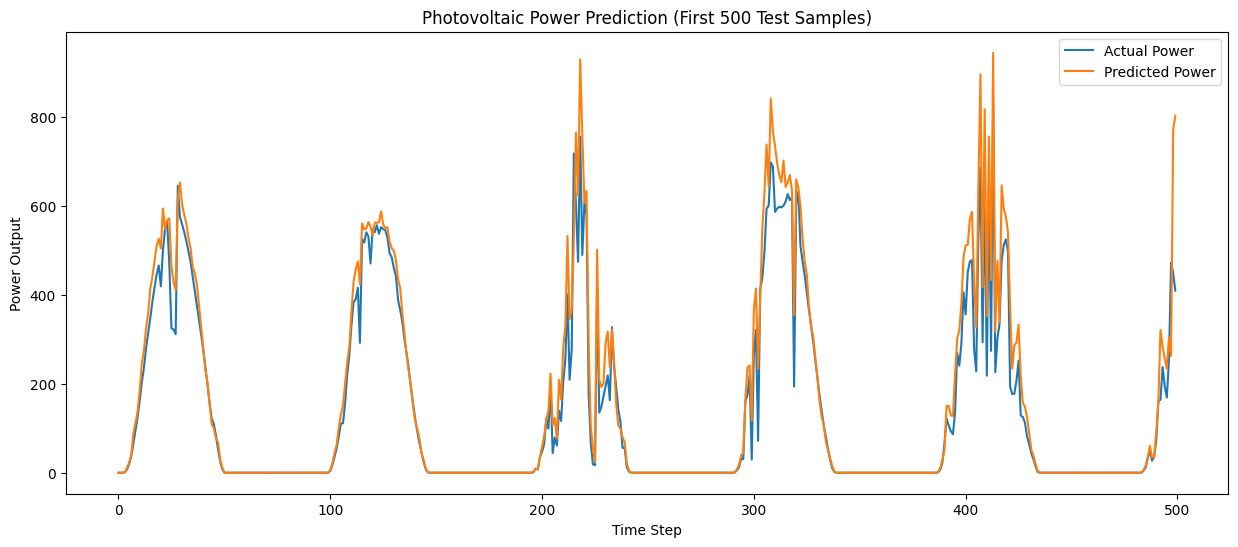

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(y_test.values[:500], label="Actual Power")
plt.plot(y_pred[:500], label="Predicted Power")

plt.legend()
plt.title("Photovoltaic Power Prediction (First 500 Test Samples)")
plt.xlabel("Time Step")
plt.ylabel("Power Output")

plt.show()

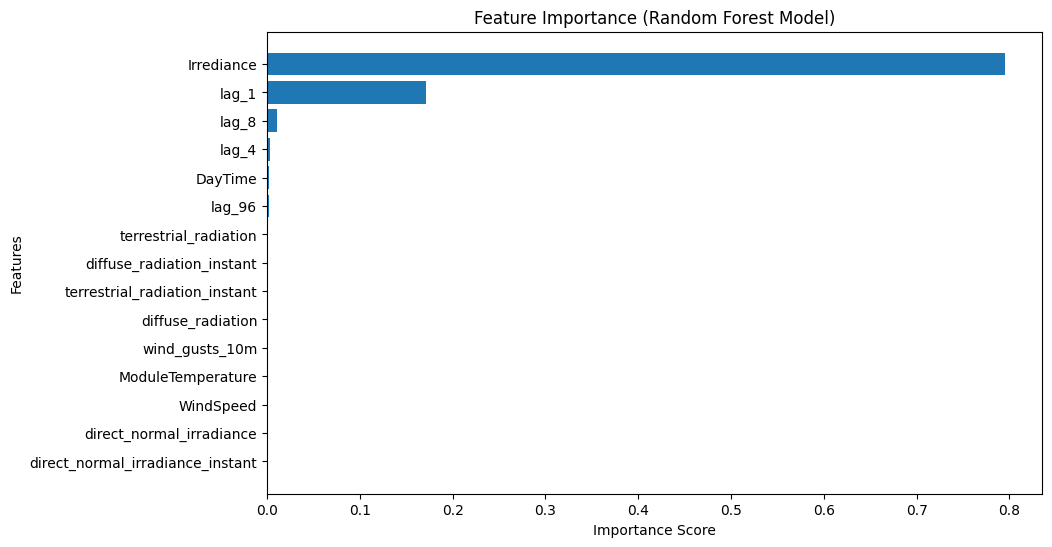

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# feature importance
importances = model.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values("Importance", ascending=False)

# top 15 feature
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()

plt.title("Feature Importance (Random Forest Model)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# tahmin yap
y_pred_xgb = xgb_model.predict(X_test)

# hata metrikleri
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 16.750200070049647
XGBoost RMSE: 41.174822640543695


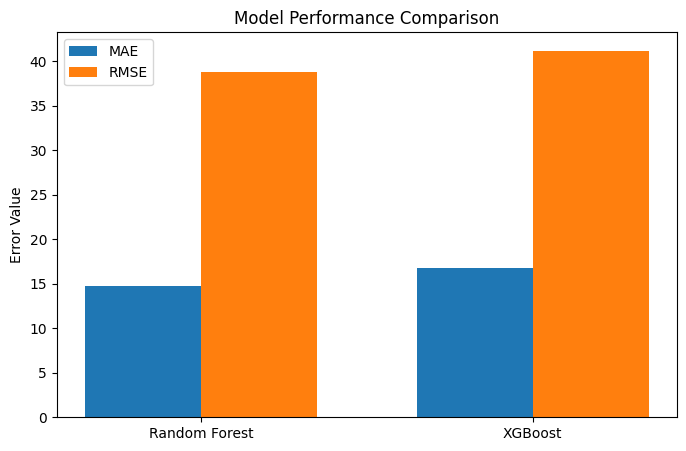

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = ["Random Forest", "XGBoost"]
mae_values = [mae, mae_xgb]
rmse_values = [rmse, rmse_xgb]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, mae_values, width, label="MAE")
plt.bar(x + width/2, rmse_values, width, label="RMSE")

plt.xticks(x, models)
plt.ylabel("Error Value")
plt.title("Model Performance Comparison")

plt.legend()

plt.show()

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# X ve y ölçekleme
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_train_scaled shape:", y_train_scaled.shape)
print("y_test_scaled shape:", y_test_scaled.shape)

X_train_scaled shape: (56232, 41)
X_test_scaled shape: (14058, 41)
y_train_scaled shape: (56232, 1)
y_test_scaled shape: (14058, 1)


In [ ]:
def create_sequences(X, y, time_steps=24):
    Xs, ys = [], []
    for i in range(time_steps, len(X)):
        Xs.append(X[i-time_steps:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

time_steps = 24

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (56208, 24, 41)
y_train_seq shape: (56208, 1)
X_test_seq shape: (14034, 24, 41)
y_test_seq shape: (14034, 1)


In [ ]:
lstm_model = Sequential()

lstm_model.add(LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(32, activation="relu"))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam", loss="mse")

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        27,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,249 (114.25 KB)

 Trainable params: 29,249 (114.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 0.0063 - val_loss: 0.0025
Epoch 2/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0043 - val_loss: 0.0020
Epoch 3/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.0039 - val_loss: 0.0019
Epoch 4/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0038 - val_loss: 0.0027
Epoch 5/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0037 - val_loss: 0.0020
Epoch 6/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0036 - val_loss: 0.0020
Epoch 7/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0035 - val_loss: 0.0019
Epoch 8/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - loss: 0.0035 - val_loss: 0.0019
Epoch 9/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0035 - val_loss: 0.0021
Epoch 10/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0035 - val_loss: 0.0020
Epoch 11/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0034 - val_loss: 0.0019
Epoch 12/20
791/791 ━━━━━━━━━━

In [ ]:
# LSTM tahminleri
y_pred_lstm_scaled = lstm_model.predict(X_test_seq)

# Orijinal ölçeğe geri çevir
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

print("y_pred_lstm shape:", y_pred_lstm.shape)
print("y_test_actual shape:", y_test_actual.shape)

439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
y_pred_lstm shape: (14034, 1)
y_test_actual shape: (14034, 1)


In [ ]:
mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

LSTM MAE: 37.438519400637716
LSTM RMSE: 76.7415692961582


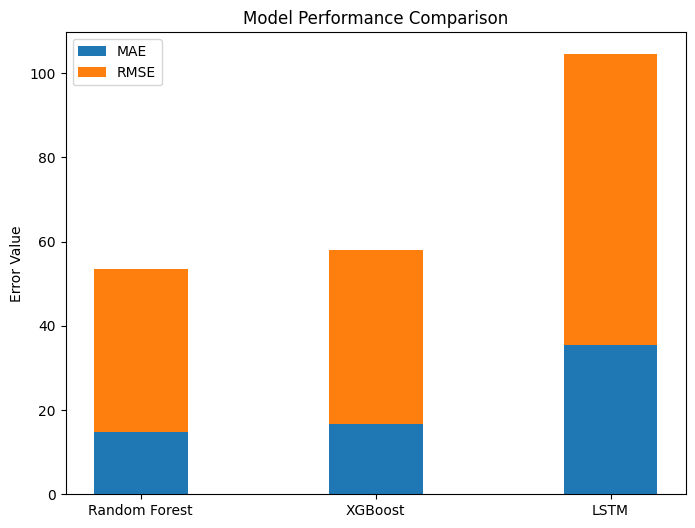

In [ ]:
import matplotlib.pyplot as plt

models = ["Random Forest", "XGBoost", "LSTM"]

mae_values = [14.78, 16.75, 35.55]
rmse_values = [38.76, 41.17, 68.95]

x = range(len(models))

plt.figure(figsize=(8,6))

plt.bar(x, mae_values, width=0.4, label="MAE")
plt.bar(x, rmse_values, width=0.4, bottom=mae_values, label="RMSE")

plt.xticks(x, models)
plt.ylabel("Error Value")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

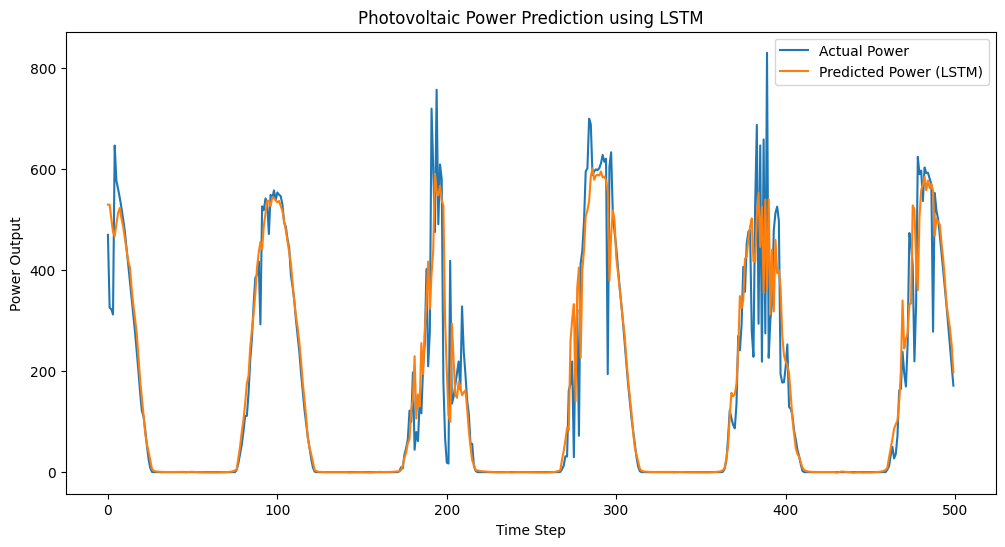

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_actual[:500], label="Actual Power")
plt.plot(y_pred_lstm[:500], label="Predicted Power (LSTM)")

plt.title("Photovoltaic Power Prediction using LSTM")
plt.xlabel("Time Step")
plt.ylabel("Power Output")

plt.legend()
plt.show()

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
import shap

X_sample = X_test.iloc[:200]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

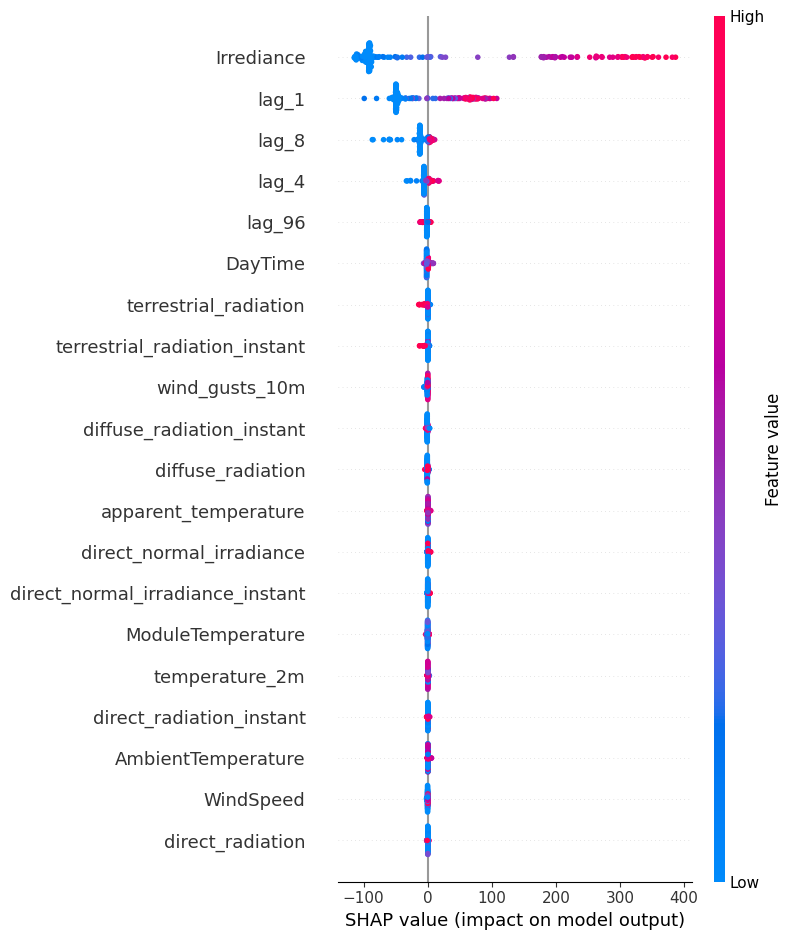

In [ ]:
shap.summary_plot(shap_values, X_sample)